# Aula 5 – Temporal Player Analysis
### Player Experience Modeling — Phil Lopes

---

## Act 2 — Working in Python

The slides covered the theory. Here is a quick recap before we open the data:

- **The normalisation trap** — each player plays ~27 matches per phase, not 333. Raw totals are misleading. Always use `PerMatch` columns.
- **Cohort stability vs individual volatility** — the population average is flat (zero-sum game), but individuals vary widely. That variance is the signal.
- **Trajectory shapes** — we summarise each player's evolution as slope, mean, and volatility, then cluster by shape rather than by level.
- **Interpretation is hard** — the same trajectory can mean skill growth, matchmaking noise, or a play-style shift. The data cannot tell you which.
- **Role context matters** — the same metric rising means different things for a Defender vs a Runner.

From here, close the slides. Everything happens in this notebook.

---

## Learning Objectives

By the end of this notebook you should be able to:

1. Demonstrate why raw totals are misleading in temporal analysis — with real data.
2. Correctly normalise per-phase metrics before comparing across phases.
3. Compute and visualise individual player trajectories.
4. Cluster players by trajectory shape, not by snapshot performance.
5. Interpret what a trajectory might (and might not) tell us about a player.

---
## Part 0 – Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)

In [34]:
df  = pd.read_csv("ctf-simulator/temporal_dataset.csv")
gt  = pd.read_csv("ctf-simulator/temporal_ground_truth.csv")

# Enforce a consistent phase order throughout
PHASE_ORDER = ["Early", "Mid", "Late"]
df["Phase"] = pd.Categorical(df["Phase"], categories=PHASE_ORDER, ordered=True)

print(f"Temporal dataset : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Ground truth     : {gt.shape[0]} rows × {gt.shape[1]} columns")
df.head(6)

Temporal dataset : 300 rows × 42 columns
Ground truth     : 100 rows × 9 columns


,PlayerName,PlayerID,PreferredRole,Phase,MatchStart,MatchEnd,Matches,Wins,Losses,Draws,...,DefenseStopsNearFlag,ReturnsUnderPressure,FlagRoomPresenceUnderThreat,TimeNearCarrierPerMatch,KillsNearCarrierPerMatch,KillsWhileCarrierAlivePerMatch,DefenseStopsNearFlagPerMatch,ReturnsUnderPressurePerMatch,FlagRoomPresenceUnderThreatPerMatch,Overextensions
0,P13,13,runner,Early,1,333,28,22,5,1,...,0,6,498,6.857,0.536,6.393,0.000,0.214,17.786,0
1,P73,73,runner,Early,1,333,27,21,4,2,...,0,5,1111,3.630,0.259,5.556,0.000,0.185,41.148,0
2,P57,57,runner,Early,1,333,27,20,4,3,...,0,6,3596,4.074,0.259,5.704,0.000,0.222,133.185,2486
3,P21,21,runner,Early,1,333,27,20,7,0,...,0,4,339,3.519,0.222,5.704,0.000,0.148,12.556,0
4,P5,5,runner,Early,1,333,27,20,6,1,...,0,5,1268,9.556,0.407,6.481,0.000,0.185,46.963,0
5,P25,25,runner,Early,1,333,27,19,8,0,...,0,6,783,4.667,0.370,6.778,0.000,0.222,29.000,0


---
## Part 1 — The Normalisation Trap

You saw this on the slides. Now let's prove it with the actual data.

First, confirm how many matches each player actually plays per phase.

In [35]:
print("Matches played per player per phase:")
print(df.groupby("Phase")["Matches"].describe().round(2))

Matches played per player per phase:
        count   mean   std    min    25%    50%    75%    max
Phase                                                        
Early 100.000 26.640 1.240 23.000 26.000 27.000 28.000 28.000
Mid   100.000 26.640 1.190 23.000 26.000 27.000 27.000 29.000
Late  100.000 26.720 1.230 23.000 26.000 27.000 28.000 29.000


C:\Users\radav\AppData\Local\Temp\ipykernel_8404\282472177.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Phase")["Matches"].describe().round(2))


Each player plays **~27 matches per phase**, not 333.
One player with 28 matches vs another with 25 looks different in raw totals — but may be identical in rate.

Let's make that concrete:

In [36]:
# Pick one player to illustrate the problem
example = df[df["PlayerName"] == "P1"][["Phase", "Matches", "Kills", "KillsPerMatch"]]
print(example.to_string(index=False))

Phase  Matches  Kills  KillsPerMatch
Early       28    526         18.786
  Mid       25    554         22.160
 Late       28    582         20.786


> **Rule: Never compare raw totals across phases. Always use the `PerMatch` normalised columns.**

This is a real pipeline problem. In production datasets, session drops, disconnects, and variable playtime
create the same issue at a much larger scale.

---

### ✏️ Exercise 1.1

Plot raw `Kills` vs `KillsPerMatch` for 5 players of your choice across the three phases.

- Do the raw totals tell a different story than the normalised values?
- Can you find a player where raw totals suggest improvement but per-match rate does not?

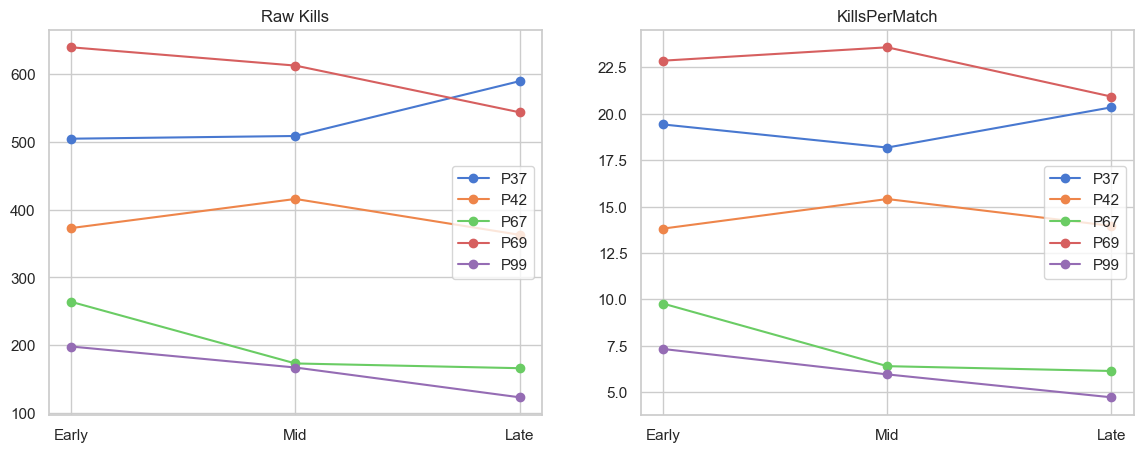

In [37]:
# TODO: Your code here
player_subset = ["P37", "P42", "P67", "P69", "P99"]  # change these

# HINTS ─────────────────────────────────────────────────────────────────────
# Step 1 — Filter to your chosen players
#   subset = df[df["PlayerName"].isin(player_subset)]
#   → pd.DataFrame.isin(list)  returns a boolean mask

# Step 2 — Loop over players and extract phase-ordered values
#   for name, group in subset.groupby("PlayerName"):
#       group = group.sort_values("Phase")   # ensures Early -> Mid -> Late
#       kills_vals     = group["Kills"].values
#       kpm_vals       = group["KillsPerMatch"].values
#   → pd.DataFrame.groupby(col)  splits the dataframe by unique values of col
#   → .values  returns a plain numpy array from a Series

# Step 3 — Plot both columns side-by-side
#   axes[0].plot(PHASE_ORDER, kills_vals, marker="o", label=name)
#   axes[1].plot(PHASE_ORDER, kpm_vals,   marker="o", label=name)
#   → marker="o"  adds a dot at each data point
#   → label=name  is used by ax.legend() to identify each player's line

# Step 4 — Polish the figure
#   axes[0].set_title("Raw Kills")  /  axes[1].set_title("KillsPerMatch")
#   axes[0].legend()               /  axes[1].legend()
#   → ax.set_title(), ax.set_xlabel(), ax.set_ylabel()  for labelling
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# your code below ...
subset = df[df["PlayerName"].isin(player_subset)]

for name, group in subset.groupby("PlayerName"):
    group = group.sort_values("Phase")
    kills_vals = group["Kills"].values
    kpm_vals = group["KillsPerMatch"].values
    
    axes[0].plot(PHASE_ORDER, kills_vals, marker="o", label=name)
    axes[1].plot(PHASE_ORDER, kpm_vals, marker="o", label=name)

axes[0].set_title("Raw Kills")
axes[1].set_title("KillsPerMatch")

axes[0].legend()
axes[1].legend()

---
## Part 2 — Cohort-Level Trends

We expect the cohort average to be flat — the game is zero-sum.
If it is, we know individual variance is real signal, not systematic drift.

In [38]:
METRICS = ["KDR", "WinRate", "CapturesPerMatch", "ObjectiveActionsPerMatch",
           "TimeNearCarrierPerMatch", "DefenseStopsNearFlagPerMatch"]

cohort = df.groupby("Phase")[METRICS].mean()
print(cohort.round(3))

        KDR  WinRate  CapturesPerMatch  ObjectiveActionsPerMatch  \
Phase                                                              
Early 1.040    0.423             1.061                     5.833   
Mid   1.042    0.422             1.115                     6.030   
Late  1.028    0.410             1.061                     5.926   

       TimeNearCarrierPerMatch  DefenseStopsNearFlagPerMatch  
Phase                                                         
Early                   11.209                         1.444  
Mid                     11.110                         1.426  
Late                    11.625                         1.307  


C:\Users\radav\AppData\Local\Temp\ipykernel_8404\4118906898.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby("Phase")[METRICS].mean()


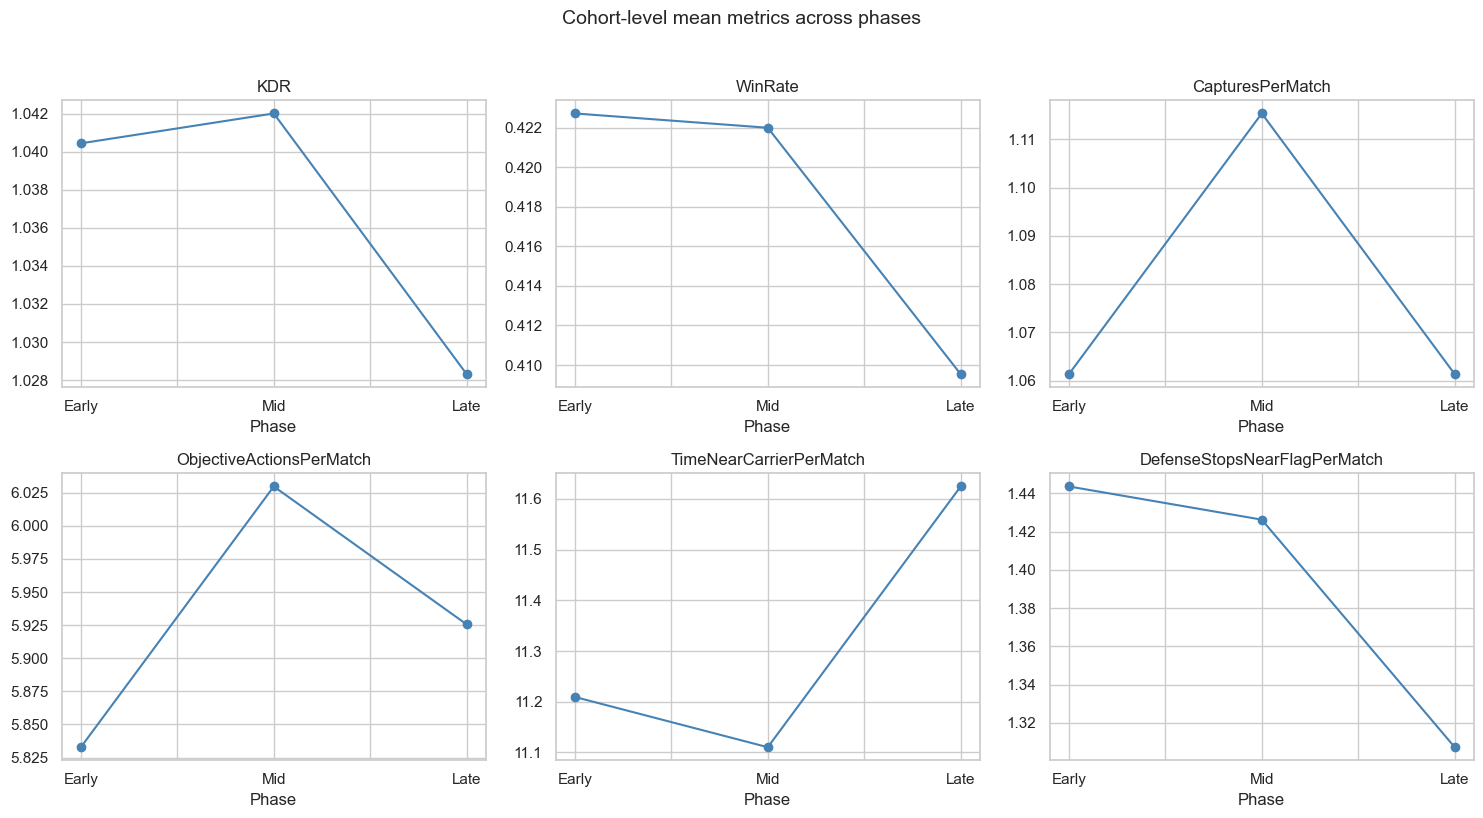

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    cohort[metric].plot(ax=axes[i], marker="o", color="steelblue")
    axes[i].set_title(metric)
    axes[i].set_xlabel("Phase")

plt.suptitle("Cohort-level mean metrics across phases", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### ✏️ Exercise 2.1 — Interpret the cohort trend

Look at the plots above and answer:

1. Are the cohort-level averages stable across phases? Why would you **expect** them to be?
2. If you observed a strong upward trend in a real dataset — say, WinRate increasing across a season — what are **two possible explanations** for it? (Hint: one is about the players, one is about the matchmaking.)
3. KDR has a mean around 1.03. Why isn't it exactly 1.0?

*Your answers here.*

---
## Part 3 — Individual Trajectories

The cohort is flat. Now let's look at what individuals are doing.
We'll summarise each player's trajectory with a single number: the **slope** from Early to Late.

In [40]:
# Pivot to wide format: one row per player, one column per (metric, phase)
kdr_pivot = df.pivot(index="PlayerID", columns="Phase", values="KDR")
kdr_pivot["delta_E_to_L"] = kdr_pivot["Late"] - kdr_pivot["Early"]

print(f"Players with KDR improvement (Early -> Late) : {(kdr_pivot['delta_E_to_L'] > 0).sum()}")
print(f"Players with KDR decline   (Early -> Late) : {(kdr_pivot['delta_E_to_L'] < 0).sum()}")
print(f"\nMean delta : {kdr_pivot['delta_E_to_L'].mean():.3f}")
print(f"Std  delta : {kdr_pivot['delta_E_to_L'].std():.3f}")

Players with KDR improvement (Early -> Late) : 48
Players with KDR decline   (Early -> Late) : 52

Mean delta : -0.012
Std  delta : 0.124


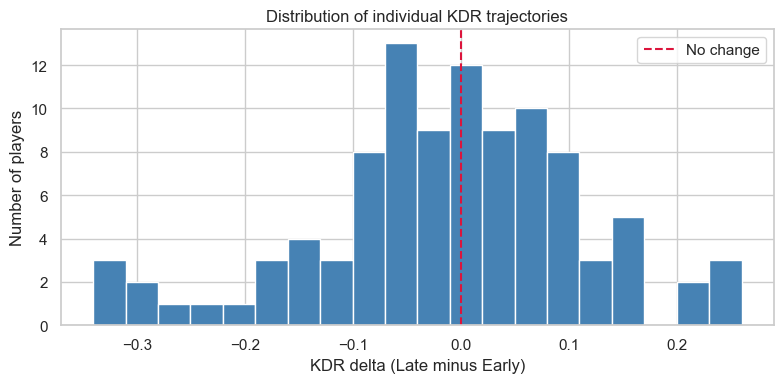

In [41]:
# Visualise the distribution of trajectory slopes
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(kdr_pivot["delta_E_to_L"], bins=20, edgecolor="white", color="steelblue")
ax.axvline(0, color="crimson", linestyle="--", label="No change")
ax.set_xlabel("KDR delta (Late minus Early)")
ax.set_ylabel("Number of players")
ax.set_title("Distribution of individual KDR trajectories")
ax.legend()
plt.tight_layout()
plt.show()

Let's plot a sample of individual trajectories to see the variety of shapes:

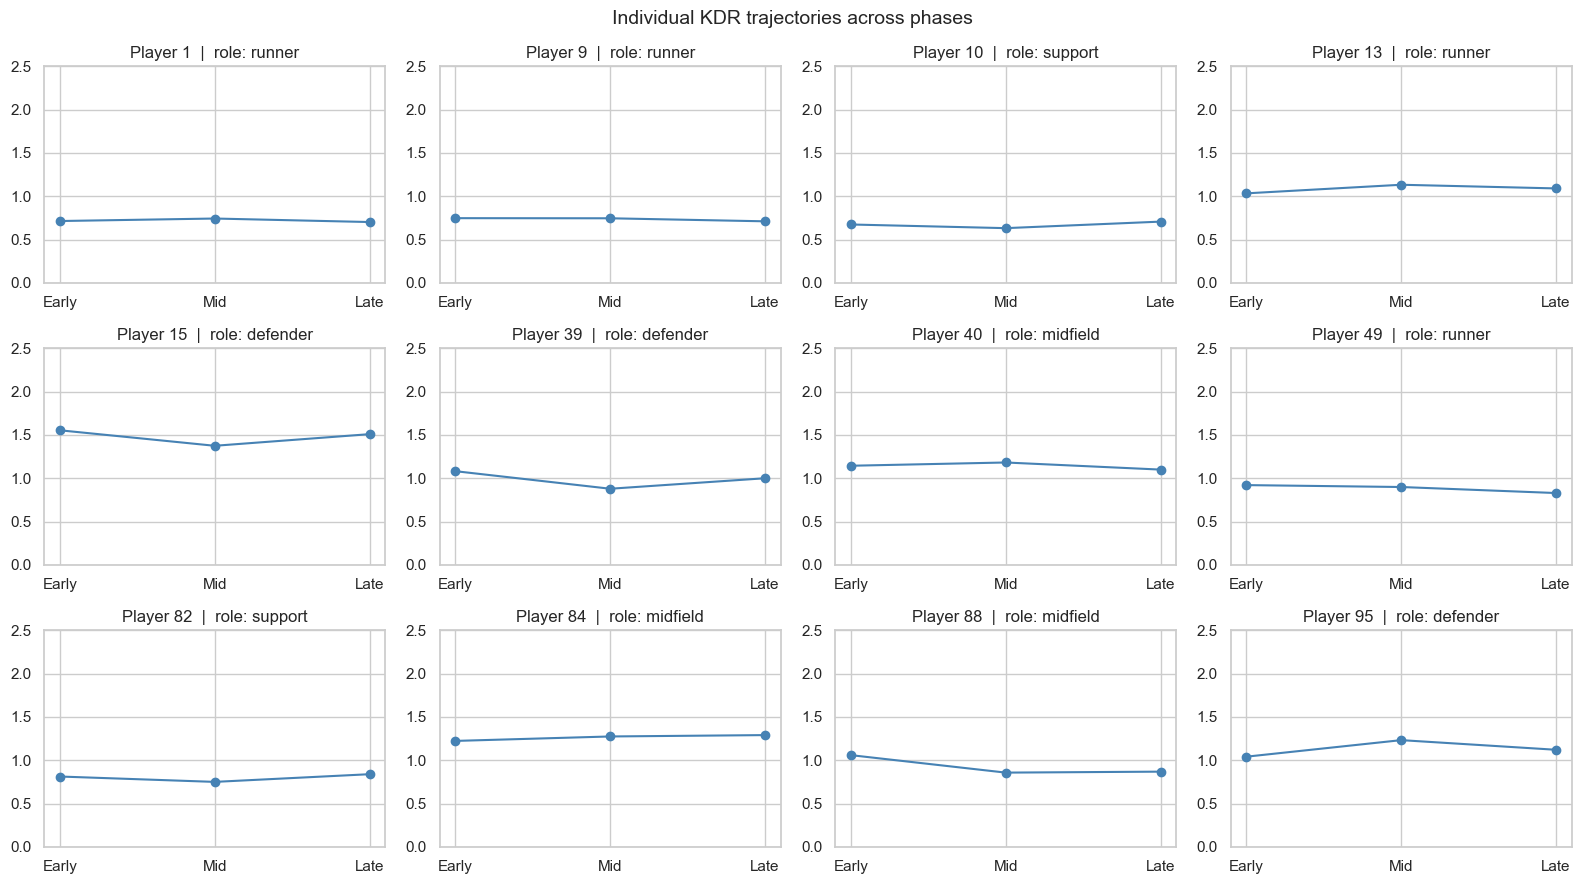

In [42]:
np.random.seed(42)
sample_ids = np.random.choice(df["PlayerID"].unique(), size=12, replace=False)
sample = df[df["PlayerID"].isin(sample_ids)]

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for i, pid in enumerate(sorted(sample_ids)):
    pdata = sample[sample["PlayerID"] == pid].sort_values("Phase")
    axes[i].plot(PHASE_ORDER, pdata["KDR"].values, marker="o", color="steelblue")
    axes[i].set_title(f"Player {pid}  |  role: {pdata['PreferredRole'].iloc[0]}")
    axes[i].set_ylim(0, 2.5)

plt.suptitle("Individual KDR trajectories across phases", fontsize=14)
plt.tight_layout()
plt.show()

### ✏️ Exercise 3.1 — Compute trajectories for multiple metrics

KDR is only one signal. Repeat the trajectory slope analysis for:
- `CapturesPerMatch`
- `WinRate`
- `TimeNearCarrierPerMatch`

For each metric, plot the distribution of Early→Late deltas. Then answer:

1. Is any metric more variable across players than KDR?
2. Are the metrics correlated — i.e. does a player with an improving KDR also tend to improve on objectives?

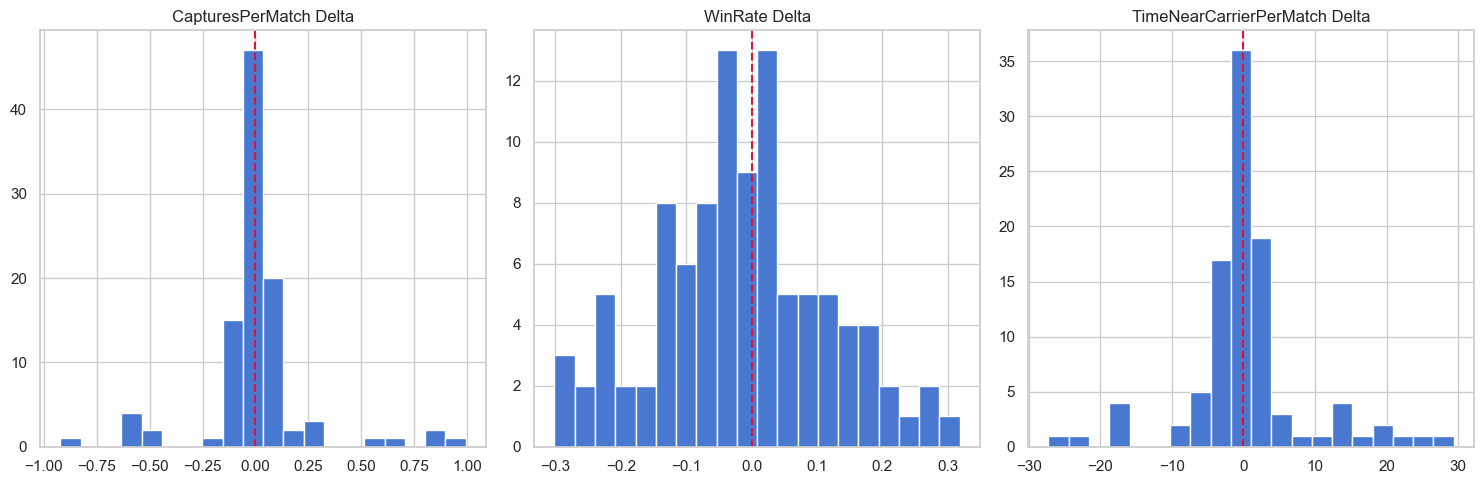

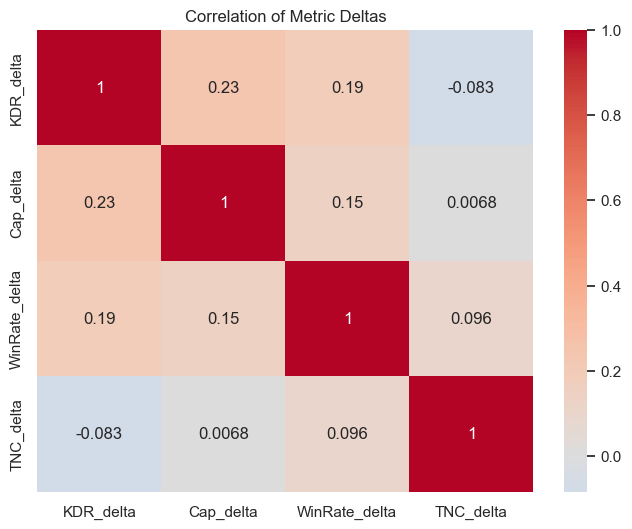

In [43]:
# TODO: Your code here

# HINTS ─────────────────────────────────────────────────────────────────────
# Step 1 — Build a pivot table for each metric (same pattern as kdr_pivot)
#   cap_pivot = df.pivot(index="PlayerID", columns="Phase", values="CapturesPerMatch")
#   → pd.DataFrame.pivot(index, columns, values)  reshapes long -> wide
#   After pivoting, add a delta column:
#   cap_pivot["delta"] = cap_pivot["Late"] - cap_pivot["Early"]

# Step 2 — Plot the delta distributions
#   ax.hist(pivot["delta"], bins=20, edgecolor="white")
#   ax.axvline(0, color="crimson", linestyle="--")   # zero-change reference line
#   → Use plt.subplots(1, 3) for three metrics side by side

# Step 3 — Check correlation between metric deltas
#   delta_df = pd.DataFrame({
#       "KDR_delta":      kdr_pivot["delta_E_to_L"],
#       "Cap_delta":      cap_pivot["delta"],
#       "WinRate_delta":  wr_pivot["delta"],
#       "TNC_delta":      tnc_pivot["delta"],
#   })
#   delta_df.corr()                      — Pearson correlation matrix
#   → pd.DataFrame.corr()  computes pairwise correlation of all columns
#   sns.heatmap(delta_df.corr(), annot=True, cmap="coolwarm", center=0)
#   → sns.heatmap(annot=True)  prints the value inside each cell
#   → cmap="coolwarm", center=0  colours negative correlations blue, positive red
# ────────────────────────────────────────────────────────────────────────────

metrics_to_check = ["CapturesPerMatch", "WinRate", "TimeNearCarrierPerMatch"]

# your code below ...
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Step 1 & 2
cap_pivot = df.pivot(index="PlayerID", columns="Phase", values="CapturesPerMatch")
cap_pivot["delta"] = cap_pivot["Late"] - cap_pivot["Early"]
axes[0].hist(cap_pivot["delta"], bins=20, edgecolor="white")
axes[0].axvline(0, color="crimson", linestyle="--")
axes[0].set_title("CapturesPerMatch Delta")

wr_pivot = df.pivot(index="PlayerID", columns="Phase", values="WinRate")
wr_pivot["delta"] = wr_pivot["Late"] - wr_pivot["Early"]
axes[1].hist(wr_pivot["delta"], bins=20, edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_title("WinRate Delta")

tnc_pivot = df.pivot(index="PlayerID", columns="Phase", values="TimeNearCarrierPerMatch")
tnc_pivot["delta"] = tnc_pivot["Late"] - tnc_pivot["Early"]
axes[2].hist(tnc_pivot["delta"], bins=20, edgecolor="white")
axes[2].axvline(0, color="crimson", linestyle="--")
axes[2].set_title("TimeNearCarrierPerMatch Delta")

plt.tight_layout()
plt.show()

# Step 3
delta_df = pd.DataFrame({
    "KDR_delta": kdr_pivot["delta_E_to_L"],
    "Cap_delta": cap_pivot["delta"],
    "WinRate_delta": wr_pivot["delta"],
    "TNC_delta": tnc_pivot["delta"],
})

plt.figure(figsize=(8, 6))
sns.heatmap(delta_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Metric Deltas")
plt.show()

---
## Part 4 — Trajectory Feature Engineering

We turn each trajectory into a **fixed-length feature vector** of three values per metric:

| Feature | Formula | What it captures |
|---------|---------|------------------|
| `slope` | Late − Early | Direction of change |
| `mean` | (E + M + L) / 3 | Overall level |
| `volatility` | std(E, M, L) | Consistency across phases |

5 metrics × 3 features = **15 features per player**.

In [44]:
TRAJ_METRICS = ["KDR", "CapturesPerMatch", "WinRate",
                "ObjectiveActionsPerMatch", "TimeNearCarrierPerMatch"]

traj_rows = []

for pid, group in df.groupby("PlayerID"):
    group = group.sort_values("Phase")
    row = {"PlayerID": pid,
           "PlayerName": group["PlayerName"].iloc[0],
           "PreferredRole": group["PreferredRole"].iloc[0]}

    for m in TRAJ_METRICS:
        vals = group[m].values.astype(float)   # [Early, Mid, Late]
        row[f"{m}_slope"]      = float(vals[-1] - vals[0])   # Late minus Early
        row[f"{m}_mean"]       = float(vals.mean())
        row[f"{m}_volatility"] = float(vals.std())

    traj_rows.append(row)

traj_df = pd.DataFrame(traj_rows).set_index("PlayerID")
print(f"Trajectory feature matrix: {traj_df.shape}")
traj_df.head()

Trajectory feature matrix: (100, 17)


,PlayerName,PreferredRole,KDR_slope,KDR_mean,KDR_volatility,CapturesPerMatch_slope,CapturesPerMatch_mean,CapturesPerMatch_volatility,WinRate_slope,WinRate_mean,WinRate_volatility,ObjectiveActionsPerMatch_slope,ObjectiveActionsPerMatch_mean,ObjectiveActionsPerMatch_volatility,TimeNearCarrierPerMatch_slope,TimeNearCarrierPerMatch_mean,TimeNearCarrierPerMatch_volatility
PlayerID,,,,,,,,,,,,,,,,,
1,P1,runner,-0.012,0.719,0.017,0.321,3.048,0.291,-0.071,0.430,0.057,2.286,14.379,0.936,-2.643,3.529,1.630
2,P2,support,-0.035,0.759,0.025,0.074,0.025,0.035,-0.029,0.236,0.052,0.681,1.630,0.314,9.642,21.108,3.936
3,P3,defender,0.240,0.885,0.099,-0.037,0.012,0.017,0.037,0.318,0.050,0.000,1.830,0.031,-8.556,8.101,3.615
4,P4,midfield,0.050,1.477,0.116,0.038,0.038,0.030,-0.038,0.444,0.054,-1.308,4.251,0.999,-3.538,9.175,1.553
5,P5,runner,-0.112,1.089,0.046,0.075,4.836,0.132,0.081,0.700,0.119,-0.265,18.517,0.358,-3.627,7.213,1.659


> **Scaling reminder:** KDR sits around 1.0 while ObjectiveActions sits around 5–10.
> Without scaling, KMeans clusters on units, not on meaning.
> We apply Min-Max scaling to bring everything into [0, 1].

In [45]:
feature_cols = [c for c in traj_df.columns if c not in ["PlayerName", "PreferredRole"]]

scaler = MinMaxScaler()
X = scaler.fit_transform(traj_df[feature_cols])

print(f"Feature matrix shape : {X.shape}")
print(f"Value range after scaling : [{X.min():.2f}, {X.max():.2f}]")

Feature matrix shape : (100, 15)
Value range after scaling : [0.00, 1.00]


---
## Part 5 — Clustering by Trajectory Shape

Use the elbow method and silhouette score to pick *k*, then fit K-Means on the scaled feature matrix.

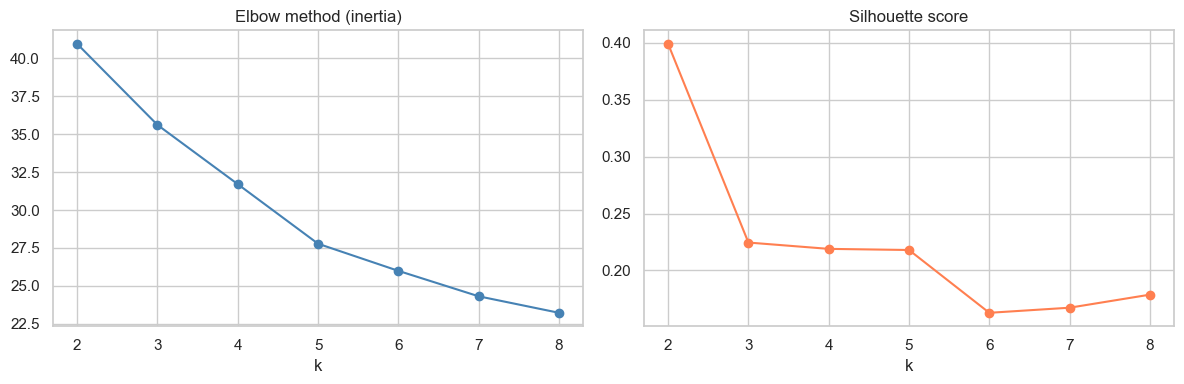


Silhouette scores:
  k=2  silhouette=0.399
  k=3  silhouette=0.224
  k=4  silhouette=0.219
  k=5  silhouette=0.218
  k=6  silhouette=0.163
  k=7  silhouette=0.167
  k=8  silhouette=0.179


In [46]:
inertias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_RANGE, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")

axes[1].plot(K_RANGE, silhouettes, marker="o", color="coral")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    print(f"  k={k}  silhouette={s:.3f}")

In [47]:
# Choose k based on the plots above
K = 4  # TODO: adjust this after inspecting the plots

km = KMeans(n_clusters=K, random_state=42, n_init=10)
traj_df["Cluster"] = km.fit_predict(X)

print("Players per cluster:")
print(traj_df["Cluster"].value_counts().sort_index())

Players per cluster:
Cluster
0     7
1    51
2    18
3    24
Name: count, dtype: int64


### Visualise what each cluster looks like

C:\Users\radav\AppData\Local\Temp\ipykernel_8404\983193722.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_traj = df.groupby(["Cluster", "Phase"])["KDR"].mean().reset_index()


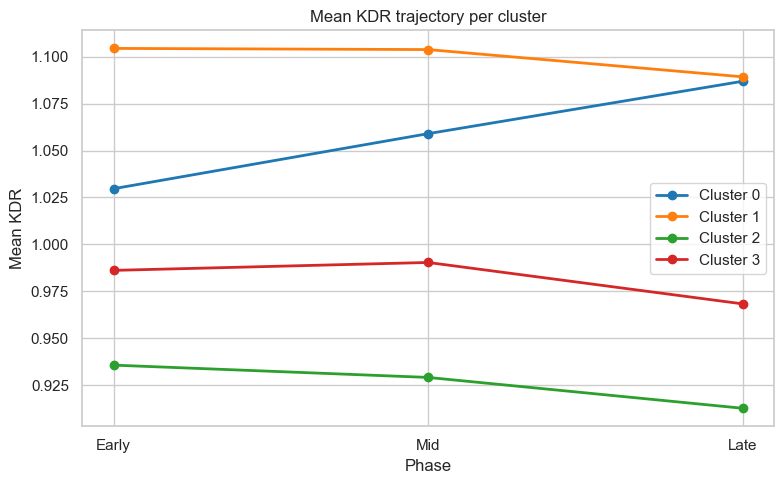

In [48]:
# Merge cluster labels back into the long-format dataset
df = df.merge(traj_df[["Cluster"]], left_on="PlayerID", right_index=True, how="left")

# Mean trajectory per cluster for KDR
cluster_traj = df.groupby(["Cluster", "Phase"])["KDR"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette("tab10", K)

for k in range(K):
    ct = cluster_traj[cluster_traj["Cluster"] == k].sort_values("Phase")
    ax.plot(ct["Phase"], ct["KDR"], marker="o", color=palette[k], linewidth=2, label=f"Cluster {k}")

ax.set_title("Mean KDR trajectory per cluster")
ax.set_xlabel("Phase")
ax.set_ylabel("Mean KDR")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\radav\AppData\Local\Temp\ipykernel_8404\1196864345.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = df.groupby(["Cluster", "Phase"])[metric].mean().reset_index()
C:\Users\radav\AppData\Local\Temp\ipykernel_8404\1196864345.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = df.groupby(["Cluster", "Phase"])[metric].mean().reset_index()
C:\Users\radav\AppData\Local\Temp\ipykernel_8404\1196864345.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

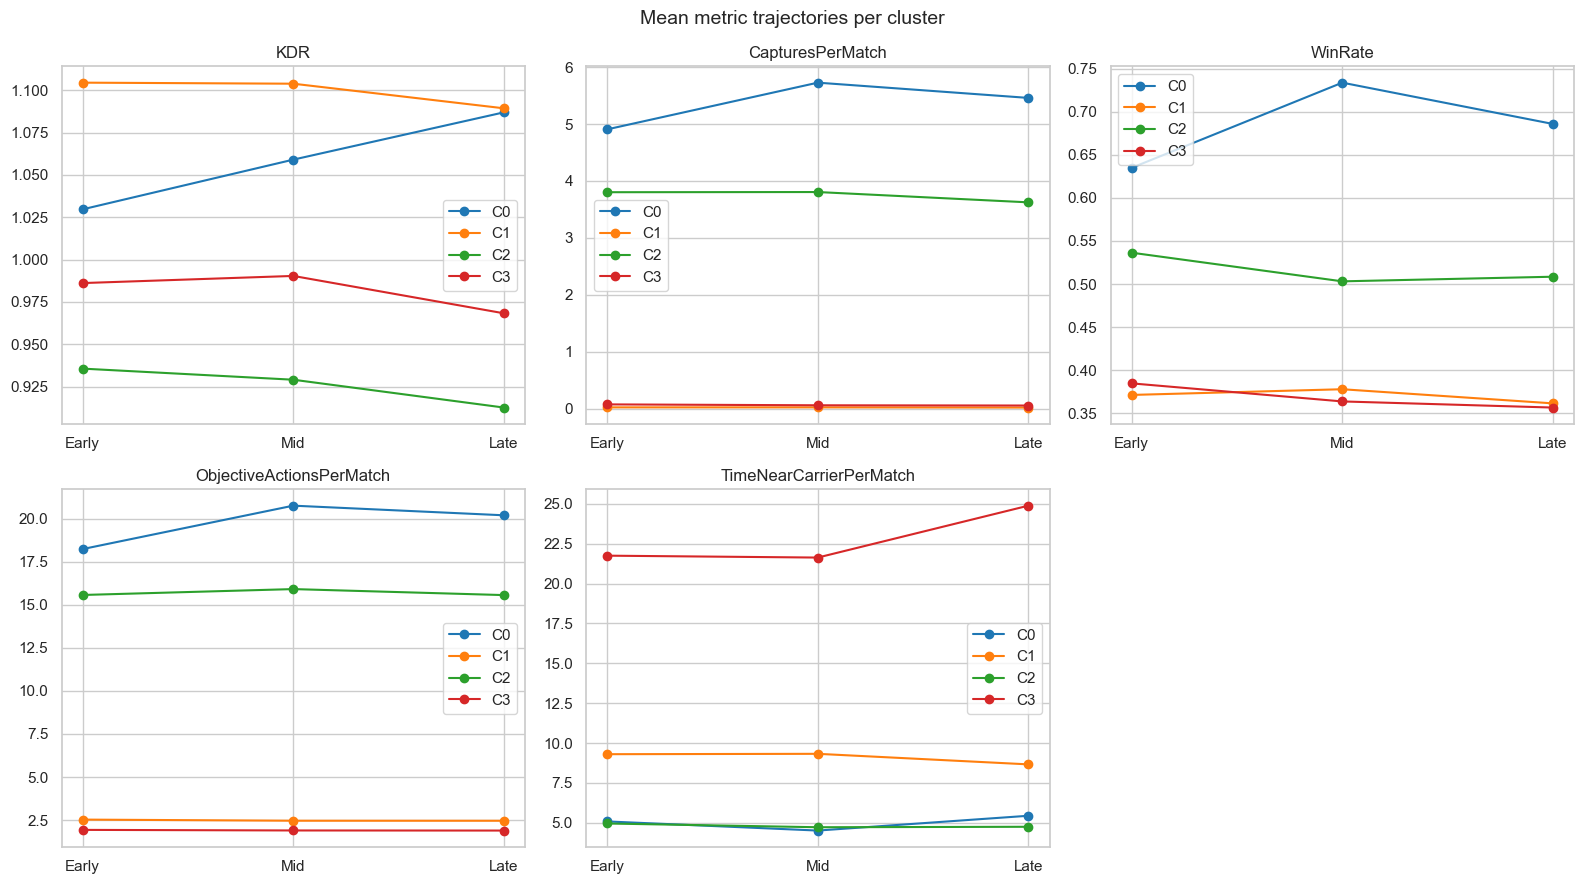

In [49]:
# Compare clusters across multiple metrics simultaneously
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(TRAJ_METRICS[:5]):
    ct = df.groupby(["Cluster", "Phase"])[metric].mean().reset_index()
    for k in range(K):
        sub = ct[ct["Cluster"] == k].sort_values("Phase")
        axes[i].plot(sub["Phase"], sub[metric], marker="o", color=palette[k], label=f"C{k}")
    axes[i].set_title(metric)
    axes[i].legend()

axes[-1].axis("off")
plt.suptitle("Mean metric trajectories per cluster", fontsize=14)
plt.tight_layout()
plt.show()

### ✏️ Exercise 5.1 — Name your clusters

Based on the trajectory plots above, give each cluster a descriptive label. For example:
- *"Late Bloomers"* — low early performance, strong finish
- *"Consistent Performers"* — stable across all phases
- *"Faders"* — strong start, weaker finish

Then answer:
1. Are certain **roles** (Runner, Support, Defender, Midfield) over-represented in any cluster?
2. Do the trajectory clusters align with true skill tiers from the ground truth?

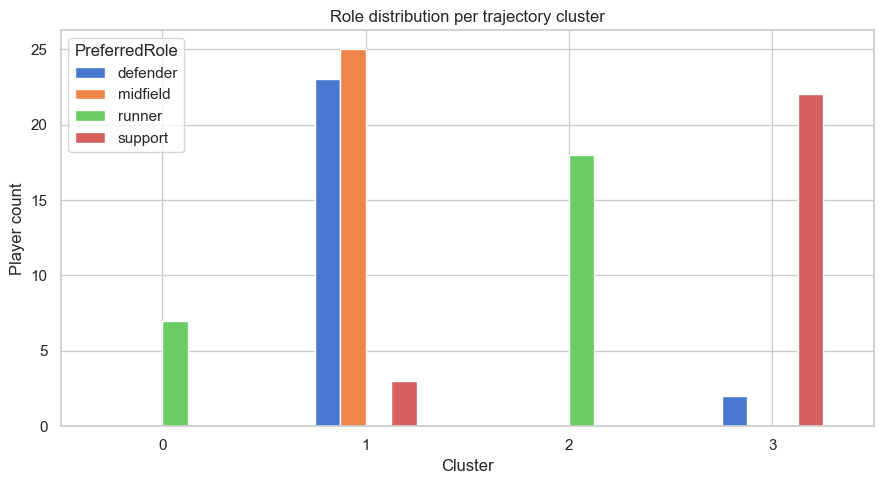

In [50]:
# Role distribution per cluster
role_cluster = traj_df.groupby(["Cluster", "PreferredRole"]).size().unstack(fill_value=0)
role_cluster.plot(kind="bar", figsize=(9, 5), edgecolor="white")
plt.title("Role distribution per trajectory cluster")
plt.xlabel("Cluster")
plt.ylabel("Player count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

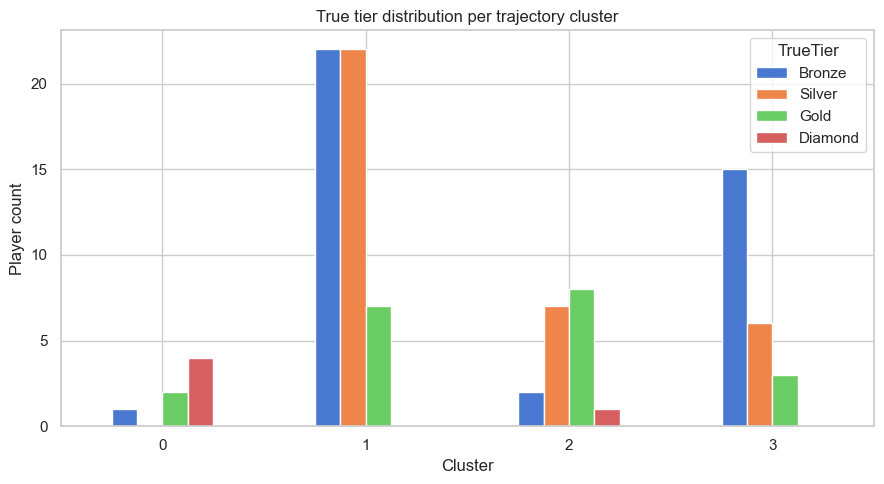

In [51]:
# Join ground truth tiers
traj_gt = traj_df.merge(gt[["PlayerID", "TrueTier"]], on="PlayerID", how="left")

tier_order = ["Bronze", "Silver", "Gold", "Diamond"]
tier_cluster = traj_gt.groupby(["Cluster", "TrueTier"]).size().unstack(fill_value=0)
tier_cluster = tier_cluster.reindex(columns=tier_order, fill_value=0)

tier_cluster.plot(kind="bar", figsize=(9, 5), edgecolor="white")
plt.title("True tier distribution per trajectory cluster")
plt.xlabel("Cluster")
plt.ylabel("Player count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Part 6 — The Interpretation Challenge

You have clusters. Now the hard part: what do they actually mean?

As the slides showed, a rising KDR trajectory has at least three equally plausible explanations.
The exercises below are designed to surface exactly that ambiguity — in the data.

### ✏️ Exercise 6.1 — Find the contradictory players

Identify players who show **rising KDR** but **falling WinRate** across phases.

1. How many such players exist?
2. What might explain this combination?
3. What additional data would you need to distinguish between the explanations above?

Contradictory players found: 21


,Early,Mid,Late,delta_E_to_L,PreferredRole,Cluster
PlayerID,,,,,,
4,1.371,1.638,1.421,0.050,midfield,1
10,0.674,0.631,0.707,0.033,support,3
13,1.034,1.133,1.091,0.057,runner,0
20,1.284,1.239,1.287,0.003,midfield,1
28,1.070,1.120,1.178,0.108,midfield,1
32,1.142,1.257,1.221,0.079,midfield,1
34,1.068,1.118,1.134,0.066,support,3
35,0.984,0.930,1.019,0.034,defender,1
42,0.949,0.956,0.968,0.019,support,3


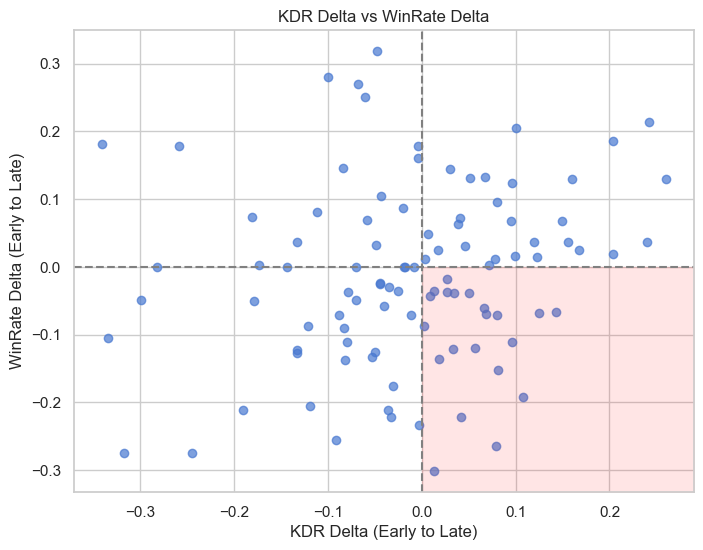

In [54]:
# TODO: Your code here

# HINTS ─────────────────────────────────────────────────────────────────────
# Step 1 — Build a WinRate pivot (same pattern as kdr_pivot from Part 3)
#   wr_pivot = df.pivot(index="PlayerID", columns="Phase", values="WinRate")
#   wr_pivot["delta"] = wr_pivot["Late"] - wr_pivot["Early"]
#   → pd.DataFrame.pivot()  reshapes long -> wide, one column per phase

# Step 2 — Boolean mask to find contradictory players
#   rising_kdr    = kdr_pivot["delta_E_to_L"] > 0
#   falling_wr    = wr_pivot["delta"] < 0
#   contradictory = kdr_pivot[rising_kdr & falling_wr]
#   → Boolean indexing: df[mask_a & mask_b]  keeps rows where BOTH are True

# Step 3 — Inspect the contradictory players
#   Print how many were found: len(contradictory)
#   Merge with traj_df to see their role and cluster:
#   contradictory.merge(traj_df[["PreferredRole", "Cluster"]], left_index=True, right_index=True)
#   → pd.DataFrame.merge(right, left_index=True, right_index=True)  joins on the index

# Step 4 — Optional visualisation
#   Scatter plot: x = KDR_delta, y = WinRate_delta, one point per player
#   Highlight the contradictory quadrant (x>0, y<0) with a shaded region:
#   ax.axhline(0, color="grey", linestyle="--")
#   ax.axvline(0, color="grey", linestyle="--")
#   → ax.axhline() / ax.axvline()  draw horizontal / vertical reference lines
# ────────────────────────────────────────────────────────────────────────────

# your code below ...
wr_pivot = df.pivot(index="PlayerID", columns="Phase", values="WinRate")
wr_pivot["delta"] = wr_pivot["Late"] - wr_pivot["Early"]

rising_kdr = kdr_pivot["delta_E_to_L"] > 0
falling_wr = wr_pivot["delta"] < 0
contradictory = kdr_pivot[rising_kdr & falling_wr]

print(f"Contradictory players found: {len(contradictory)}")

contradictory_details = contradictory.merge(traj_df[["PreferredRole", "Cluster"]], left_index=True, right_index=True)
display(contradictory_details)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(kdr_pivot["delta_E_to_L"], wr_pivot["delta"], alpha=0.7)

ax.axhline(0, color="grey", linestyle="--")
ax.axvline(0, color="grey", linestyle="--")

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.fill_between([0, xlim[1]], ylim[0], 0, color="red", alpha=0.1)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel("KDR Delta (Early to Late)")
ax.set_ylabel("WinRate Delta (Early to Late)")
ax.set_title("KDR Delta vs WinRate Delta")

plt.show()

### ✏️ Exercise 6.2 — Role-specific trajectory interpretation

For **Defenders**, an improving `DefenseStopsNearFlagPerMatch` over time is meaningful.
For a **Runner**, that same metric improving might just mean they're spending less time in the enemy base — which could be *worse* performance.

Filter the dataset to one role of your choice and repeat the trajectory analysis. Does the pattern look different from the full cohort?

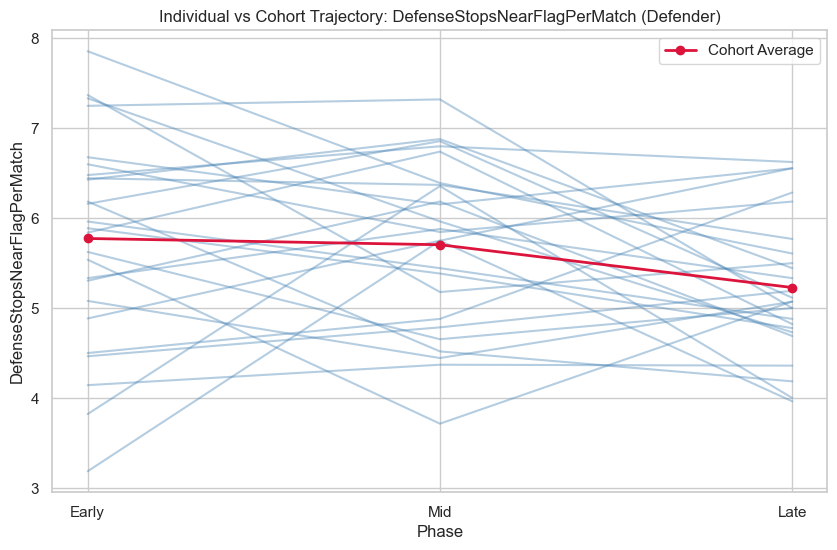

Delta summary for DefenseStopsNearFlagPerMatch:
count   25.000
mean    -0.545
std      1.142
min     -2.603
25%     -1.083
50%     -0.615
75%      0.145
max      1.786
Name: DefenseStopsNearFlagPerMatch, dtype: float64


In [55]:
# TODO: Your code here
role = "defender"  # change this to Runner, Support, or Midfield
role_df = df[df["PreferredRole"] == role].copy()

# HINTS ─────────────────────────────────────────────────────────────────────
# Step 1 — Pick the most role-relevant metric for your chosen role
#   defender  -> "DefenseStopsNearFlagPerMatch", "FlagRoomPresenceUnderThreatPerMatch"
#   runner    -> "CapturesPerMatch", "GrabsPerMatch"
#   support   -> "TimeNearCarrierPerMatch", "KillsNearCarrierPerMatch"
#   midfield  -> "InterceptionsPerMatch", "KDR"

# Step 2 — Compute the cohort trajectory for this role only
#   role_cohort = role_df.groupby("Phase", observed=True)[metric].mean()
#   role_cohort.plot(marker="o")

# Step 3 — Plot individual trajectories for this role
#   for pid, group in role_df.groupby("PlayerID"):
#       group = group.sort_values("Phase")
#       ax.plot(PHASE_ORDER, group[metric].values, alpha=0.4, color="steelblue")

# Step 4 — Compute Early->Late delta WITHOUT pivot
#   Use groupby instead of set_index to avoid issues when cells are re-run:
#   phase_str = role_df["Phase"].astype(str)
#   early = role_df[phase_str == "Early"].groupby("PlayerID")[metric].mean()
#   late  = role_df[phase_str == "Late" ].groupby("PlayerID")[metric].mean()
#   delta = (late - early).dropna()
#   → .groupby().mean() tolerates duplicate rows from re-running earlier cells
#   → .dropna() drops players missing from either phase
#   → pd.Series.describe()  gives count, mean, std, min, quartiles, max in one call
# ────────────────────────────────────────────────────────────────────────────

# your code below ...
metric = "DefenseStopsNearFlagPerMatch"

fig, ax = plt.subplots(figsize=(10, 6))

for pid, group in role_df.groupby("PlayerID"):
    group = group.sort_values("Phase")
    ax.plot(PHASE_ORDER, group[metric].values, alpha=0.4, color="steelblue")

role_cohort = role_df.groupby("Phase", observed=True)[metric].mean()
role_cohort = role_cohort.reindex(PHASE_ORDER)
ax.plot(PHASE_ORDER, role_cohort.values, marker="o", color="crimson", linewidth=2, label="Cohort Average")

ax.set_title(f"Individual vs Cohort Trajectory: {metric} ({role.capitalize()})")
ax.set_xlabel("Phase")
ax.set_ylabel(metric)
ax.legend()
plt.show()

phase_str = role_df["Phase"].astype(str)
early = role_df[phase_str == "Early"].groupby("PlayerID")[metric].mean()
late = role_df[phase_str == "Late"].groupby("PlayerID")[metric].mean()
delta = (late - early).dropna()

print(f"Delta summary for {metric}:")
print(delta.describe())

---
## Part 7 — Takeaways & Discussion

1. **Never compare raw totals across temporal windows.** Use normalised per-match rates.
2. **Cohort stability does not mean individual stability.** The population average is flat; individuals are not.
3. **Trajectory shape is information.** But slope alone cannot tell you *why* a player changed.
4. **Role context is essential.** The same metric trajectory carries different meaning for different roles.
5. **Telemetry is a behavioural record, not a psychological one.** It records what happened — not why.

---

### Final Discussion Question

> *A game studio wants to flag players who are 'declining' so they can send a re-engagement notification.
> Your temporal model identifies 20 such players. What questions would you ask before deploying this system?*

Think about: data quality, false positives, ethical implications, and whether the metric you used
actually captures what 'declining engagement' means to the player.